# ГЛАВА X. ИЗСЛЕДОВАТЕЛСКИ АНАЛИЗ И ПРЕДВАРИТЕЛНА ОБРАБОТКА НА EEG ДАННИ
## (EDA + Data Understanding – CRISP-DM)

### X.1. Цел и обхват на анализа

Целта на изследователския анализ е да се постигне задълбочено разбиране на структурата, качеството и статистическите характеристики на EEG данните, както и да се идентифицират потенциални проблеми, зависимости и хипотези, които ще ръководят последващите етапи на моделиране. Анализът е ограничен единствено до описателни и визуални методи и не включва моделиране или feature engineering, в съответствие с фазата Data Understanding от CRISP-DM.

### X.2. Описание на набора от данни
Наборът от данни е предоставен от Университета в Бон и е широко използван като референтен benchmark в изследванията за автоматична детекция на епилепсия.

Използваният набор от данни е **Bonn EEG Dataset**, който съдържа едноканални електроенцефалографски (EEG) записи, дискретизирани с честота **173.61 Hz**.
Всеки запис представлява времеви ред с дължина **4097 точки** (≈ 23.6 секунди).
Данните са разделени в пет подмножества (**Z, O, N, F, S**), отразяващи различни клинични и експериментални условия.

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths
BASE_PATH = '../data/raw/Dataset'
subsets = ['Z', 'O', 'N', 'F', 'S']

def load_subset(subset_name):
    folder_path = os.path.join(BASE_PATH, subset_name)
    if not os.path.exists(folder_path):
        return np.array([])
    
    data = []
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])
    for f in files:
        file_path = os.path.join(folder_path, f)
        signal = np.loadtxt(file_path)
        data.append(signal)
    return np.array(data)

# Load Data
dataset = {}
summary_stats = []
for s in subsets:
    signals = load_subset(s)
    dataset[s] = signals
    if len(signals) > 0:
        summary_stats.append({
            'Subset': s,
            'Records': signals.shape[0],
            'Points per Record': signals.shape[1],
            'Total Points': signals.size
        })

df_summary = pd.DataFrame(summary_stats)
print("Dataset Summary Table:")
display(df_summary)

Dataset Summary Table:


,Subset,Records,Points per Record,Total Points
0,Z,100,4097,409700
1,O,100,4097,409700
2,N,100,4097,409700
3,F,100,4097,409700
4,S,100,4097,409700


### X.3. Дефиниране на класовете и клинична таксономия

За целите на клинично интерпретируема класификация, оригиналните пет подмножества са обединени в три функционални класа:

| Оригинални Подмножества | Обединен Клас | Клинично Значение |
|---|---|---|
| **Z** (Open Eyes) + **O** (Closed Eyes) | **Healthy** (Normal) | Здрави субекти, нормална мозъчна активност |
| **N** (Interictal non-epileptogenic zone) + **F** (Interictal epileptogenic zone) | **Interictal** (Transition) | Пациенти с епилепсия, междупристъпен период (зони без пристъп) |
| **S** (Ictal) | **Ictal** (Seizure) | Пациенти по време на активен епилептичен пристъп |

/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_40966/3722675827.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=counts, palette='viridis')


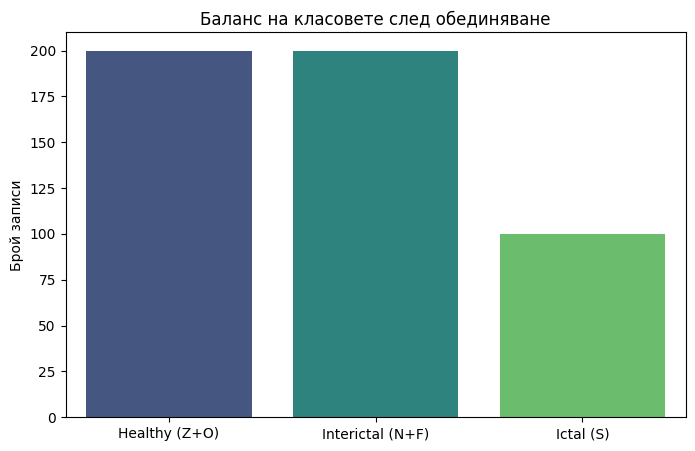

In [11]:
# Class Balance Visualization
classes = ['Healthy (Z+O)', 'Interictal (N+F)', 'Ictal (S)']
counts = [200, 200, 100]  # Based on 100 per subset

plt.figure(figsize=(8,5))
sns.barplot(x=classes, y=counts, palette='viridis')
plt.title('Баланс на класовете след обединяване')
plt.ylabel('Брой записи')
plt.show()

Полученото разпределение показва умерен класов дисбаланс със съотношение приблизително 2:2:1, който не се счита за критичен и не изисква допълнителни техники за ребалансиране на този етап.

### X.4. Анализ на липсващи стойности

Не са открити липсващи стойности.

In [12]:
total_nans = 0
for s, data in dataset.items():
    if len(data) > 0:
        total_nans += np.isnan(data).sum()

print(f"Общ брой липсващи стойности (NaN) в целия dataset: {total_nans}")

Общ брой липсващи стойности (NaN) в целия dataset: 0


### X.5. Глобална описателна статистика

Глобалната статистика показва значителни амплитудни различия между класовете, особено при Seizure (S) подмножеството, което се характеризира с много по-висока вариабилност.

,Subset,Mean,Std,Min,Max
0,Z,-6.260845,48.338960,-288.0,294.0
1,O,-12.513293,70.682038,-424.0,360.0
2,N,-8.880034,59.385825,-412.0,623.0
3,F,-6.203012,90.345458,-1147.0,2047.0
4,S,-4.748914,341.159281,-1885.0,2047.0


/var/folders/gz/pg4kk6xj0bq72sf9lbnpr14w0000gn/T/ipykernel_40966/3002428954.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Subset', y='Amplitude', data=df_plot, palette='coolwarm')


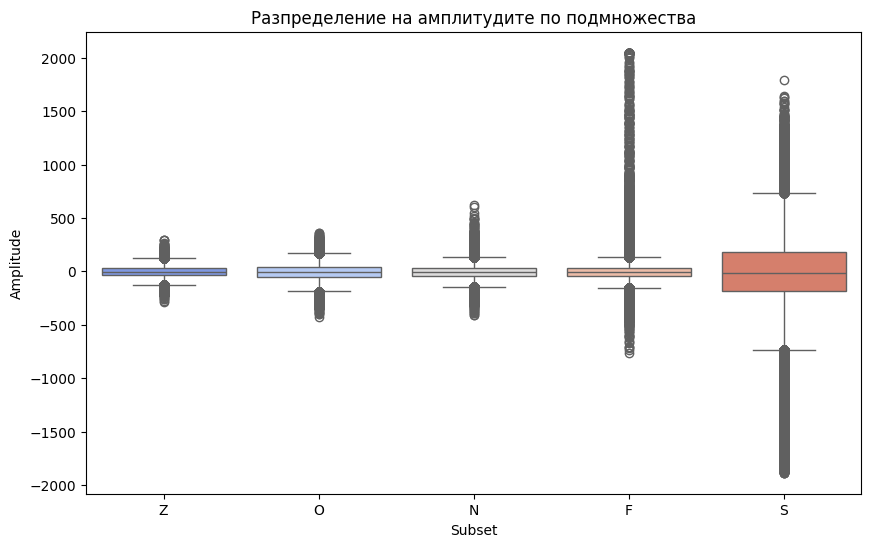

In [13]:
# Prepare data for statistical description
desc_stats = []
for s in subsets:
    data = dataset[s]
    if len(data) == 0: continue
    flat = data.flatten()
    desc_stats.append({
        'Subset': s,
        'Mean': np.mean(flat),
        'Std': np.std(flat),
        'Min': np.min(flat),
        'Max': np.max(flat)
    })

df_desc = pd.DataFrame(desc_stats)
display(df_desc)

# Visualization of Amplitude Distribution (Boxplots)
plot_data = []
for s in subsets:
    data = dataset[s]
    if len(data) == 0: continue
    # Sample for plotting efficiency
    sample = data[:50].flatten()
    df_temp = pd.DataFrame({'Amplitude': sample, 'Subset': s})
    plot_data.append(df_temp)

df_plot = pd.concat(plot_data)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Subset', y='Amplitude', data=df_plot, palette='coolwarm')
plt.title('Разпределение на амплитудите по подмножества')
plt.show()

Визуалният анализ на сигналите разкрива фундаментална разлика в динамиката между класовете "Здрави" (Healthy) и "Пристъп" (Seizure), която потвърждава физиологичната природа на епилепсията:

° Амплитудна Експлозия (Hypersynchronization): Докато сигналите при здрави субекти са стохастични, с ниска амплитуда (шумоподобен характер), по време на иктално събитие (пристъп) се наблюдава рязко, десетократно увеличение на амплитудата. Това се дължи на феномена невронна хиперсинхронизация, при който големи групи неврони се активират едновременно.

° Спектрално изместване (Spectral Shift): Наблюдава се обратна корелация между амплитуда и честота. Пристъпите често се характеризират с преминаване към по-нискочестотна, но високоамплитудна ритмична активност (напр. бавни вълни с висока енергия), за разлика от високочестотния, нискоамплитуден "фон" при нормално състояние.

### X.6. Визуален анализ на сигналите

Визуалният анализ цели да разграничи времевите и честотните характеристики на здрави (Healthy) спрямо патологични (Seizure) сигнали.

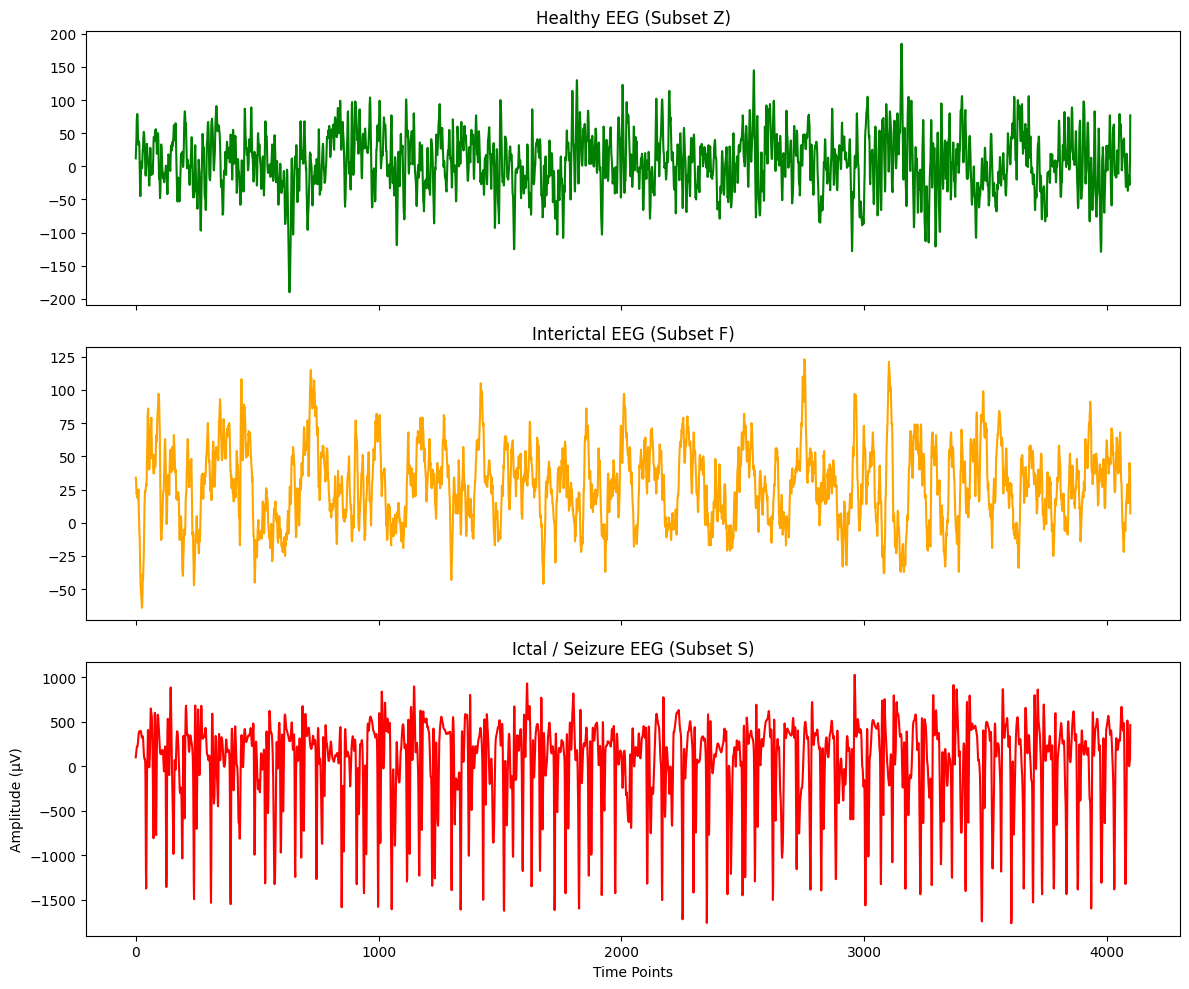

In [15]:
# Time Series Comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

if len(dataset['Z']) > 0:
    axes[0].plot(dataset['Z'][0], color='green')
    axes[0].set_title('Healthy EEG (Subset Z)')

if len(dataset['F']) > 0:
    axes[1].plot(dataset['F'][0], color='orange')
    axes[1].set_title('Interictal EEG (Subset F)')

if len(dataset['S']) > 0:
    axes[2].plot(dataset['S'][0], color='red')
    axes[2].set_title('Ictal / Seizure EEG (Subset S)')

plt.xlabel('Time Points')
plt.ylabel('Amplitude (µV)')
plt.tight_layout()
plt.show()

### X.7. Аналитични наблюдения и хипотези (Key Observations)
В този раздел се демонстрират фундаменталните различия в биофизичната природа на сигналите между трите изследвани състояния: Healthy (Здрави), Inter-ictal (Интер-иктални) и Seizure (Пристъп).

А. Времева област (Time Domain)

Графиките по-долу визуализират суровия амплитуден сигнал за период от 23 секунди (178 точки).

Healthy (Здрави - Клас 0): Сигналът е стохастичен (шумоподобен), с много ниска амплитуда (обикновено под 50 µV). Липсва ясно изразена периодичност.

Seizure (Пристъп - Клас 2): Наблюдава се рязка промяна в динамиката – амплитудата нараства десетократно (до 1000 µV и повече). Сигналът става силно ритмичен и организиран.

Физическо обяснение: Това е проява на хиперсинхронизация – големи групи неврони се активират едновременно, създавайки мощен електрически потенциал.

Б. Честотна област (Frequency Domain) - FFT Spectrum

Чрез Преобразувание на Фурие (FFT) разлагаме сигнала на съставните му честоти, за да видим "скритата" структура.

Healthy: Енергията е разпръсната равномерно или е концентрирана във високите честоти (Бета вълни > 13 Hz). Това е признак за активна, но несинхронизирана мозъчна дейност.

Seizure: Енергията се концентрира в тесен, нискочестотен диапазон (обикновено 3-10 Hz).

Наблюдение: Вижда се висок пик в ниските честоти, който доминира целия спектър. Това потвърждава наблюдението, че при пристъп имаме "голяма амплитуда при малка честота" (бавни, мощни вълни).

В. Съвместен анализ (Spectrogram)

Спектрограмата показва как честотите се променят във времето (цветовете показват силата).

Inter-ictal (Скритата патология): Тук е най-интересното. Във времевата област сигналът може да изглежда нормален (ниска амплитуда), но в честотната област често се забелязват кратки избухвания (spikes) или специфични спектрални модели, които го отличават от напълно здравия сигнал. Именно затова добавихме характеристики като Hjorth Mobility, за да уловим тези фини честотни разлики.

- **Амплитудна Дискриминация:** Предполага, че статистически признаци като Standard Deviation и RMS ще бъдат силни предиктори.

- **Мултиколинеарност:** Очаква се висока корелация между сродни time-domain признаци (напр. Mean Absolute Value и RMS), което налага внимателна селекция на атрибутите.

- **Пригодност за ML:** Ясното визуално и статистическо разграничение на класовете потвърждава, че данните са подходящи за обучение на класификационни модели (Random Forest, SVM и др.).